# Proyecto Final: Predicción de Intención de Compra de Visitantes en E-Commerce

**Pregunta del Problema:**
¿Es posible predecir si un visitante de una tienda en linea realizará una compra de acuerdo con su comportamiento en la sesión?

**Línea seleccionada:** Aprendizaje Supervisado (Clasificación).

En este notebook se presenta el proceso para desarrollar un modelo predictivo que permita dar respuesta a la cuestión presentada

In [23]:
# Paso 0 - Importación de librerías esenciales

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de clasificación y metricas de evaluación utilizadas 

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación y utilidades
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('Blues_r')


1. Carga de Datos y Análisis Exploratorio Inicial

Se tomara como dataset: Online Shoppers Purchasing Intention

In [24]:
# Paso 1 
#Cargamos el Dataset mediente Pandas 

df = pd.read_csv(r"C:\Users\misae\Downloads\online_shoppers_intention.csv")

# Eliminación de filas duplicadas
print(f"Filas iniciales: {len(df)}")
df = df.drop_duplicates()
print(f"Filas finales tras eliminar duplicados: {len(df)}")

# Verificación de valores nulos
print(f"Valores nulos totales: {df.isnull().sum().sum()}")



Filas iniciales: 12330
Filas finales tras eliminar duplicados: 12205
Valores nulos totales: 0


Exploración de datos 

Dimensiones del dataset: (12205, 18)

Información general de tipos de datos:
<class 'pandas.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  str    
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region         

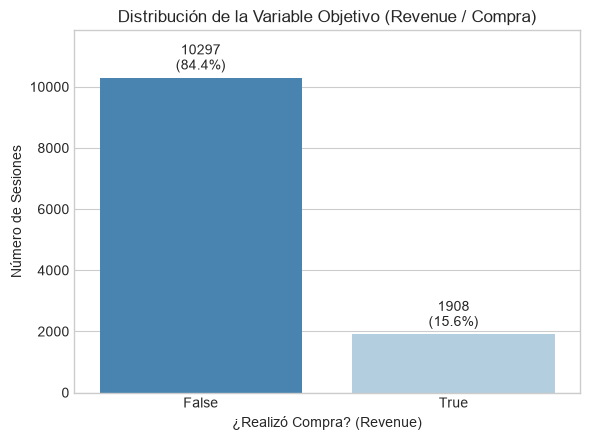

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [37]:
# Validación inicial 
print("Dimensiones del dataset:", df.shape)
print("\nInformación general de tipos de datos:")
df.info()

print("\nVerificación de valores nulos:")
print(df.isnull().sum().sum(), "valores nulos detectados.")

# Visualización de la variable objetivo (Revenue-compra)
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(
    data=df,
    x='Revenue',
    hue='Revenue',
    palette='Blues_r',
    legend=False
)
plt.title('Distribución de la Variable Objetivo (Revenue / Compra)', fontsize=12)
plt.xlabel('¿Realizó Compra? (Revenue)', fontsize=10)
plt.ylabel('Número de Sesiones', fontsize=10)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points')


plt.ylim(0, max(df['Revenue'].value_counts()) * 1.15)
plt.tight_layout()
plt.show()

# Resumen
df.describe()

Preprocesamiento de Datos e Ingeniería de Características

En esta sección transformamos las variables categóricas en numéricas


In [26]:
# Paso 2: Transformación de variables categóricas y estructuración de X e y

df_proc = df.copy()

# Conversión de booleanos a 0 y 1
df_proc['Weekend'] = df_proc['Weekend'].astype(int)
df_proc['Revenue'] = df_proc['Revenue'].astype(int)

# Aplicación de One-Hot Encoding a variables categóricas (Month y VisitorType)
df_proc = pd.get_dummies(df_proc, columns=['Month', 'VisitorType'], drop_first=True)

# Definición de X (matriz de características) e y (variable objetivo)
X = df_proc.drop(columns=['Revenue'])
y = df_proc['Revenue']

print(f"Dimensiones de la matriz X: {X.shape}")
print(f"Dimensiones del vector y: {y.shape}")

Dimensiones de la matriz X: (12205, 26)
Dimensiones del vector y: (12205,)


3. División del Dataset

Separación de los datos en conjuntos de entrenamiento (80%) y prueba (20%) utilizando estratificación para mantener la proporción de la variable objetivo 

In [27]:

# Paso 3: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# Normalización de características (Escalado) 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 9764
Muestras de prueba: 2441


4. Entrenamiento de Modelos

Entrenamiento de tres modelos de clasificación distintos
1. **Regresión Logística** 
2. **Árbol de Decisión** 
3. **Random Forest** 

In [28]:
# Paso 4: Entrenamiento y generación de predicciones

# Modelo 1: Regresión Logística
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

# Modelo 2: Árbol de Decisión
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

# Modelo 3: Random Forest
model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("Entrenamiento finalizado para los tres modelos")

Entrenamiento finalizado para los tres modelos


5. Evaluación y Comparación de Resultados

Cálculo de métricas cuantitativas (**Accuracy**, **Precision**, **Recall**, **F1-Score**) y visualización mediante gráficos comparativos y matrices de confusión


In [29]:
# Paso 5: Cálculo de métricas para cada modelo
models = {
    'Regresión Logística': y_pred_lr,
    'Árbol de Decisión': y_pred_dt,
    'Random Forest': y_pred_rf
}

metrics_list = []

for name, y_pred in models.items():
    metrics_list.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

metrics_df = pd.DataFrame(metrics_list)
print("--- RESUMEN DE RENDIMIENTO DE LOS MODELOS ---")
print(metrics_df.round(4).to_string(index=False))

--- RESUMEN DE RENDIMIENTO DE LOS MODELOS ---
             Modelo  Accuracy  Precision  Recall  F1-Score
Regresión Logística    0.8894     0.7718  0.4162    0.5408
  Árbol de Decisión    0.9021     0.7061  0.6414    0.6722
      Random Forest    0.9037     0.7526  0.5733    0.6508


Gráfica Comparativa de Accuracy

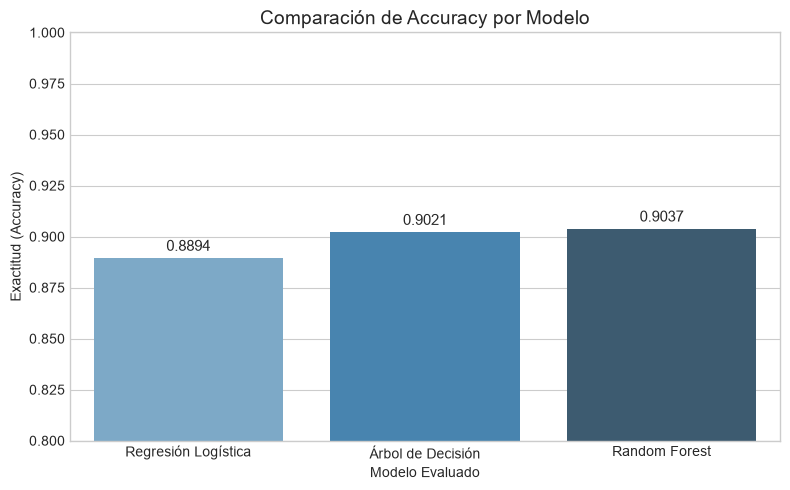

In [36]:
# Paso 6: Gráfica comparativa de Accuracy
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=metrics_df,
    x='Modelo',
    y='Accuracy',
    hue='Modelo',
    palette='Blues_d',
    legend=False
)
plt.title('Comparación de Accuracy por Modelo', fontsize=14)
plt.ylim(0.8, 1.0) # Enfocar el rango relevante
plt.ylabel('Exactitud (Accuracy)')
plt.xlabel('Modelo Evaluado')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, xytext=(0, 3), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

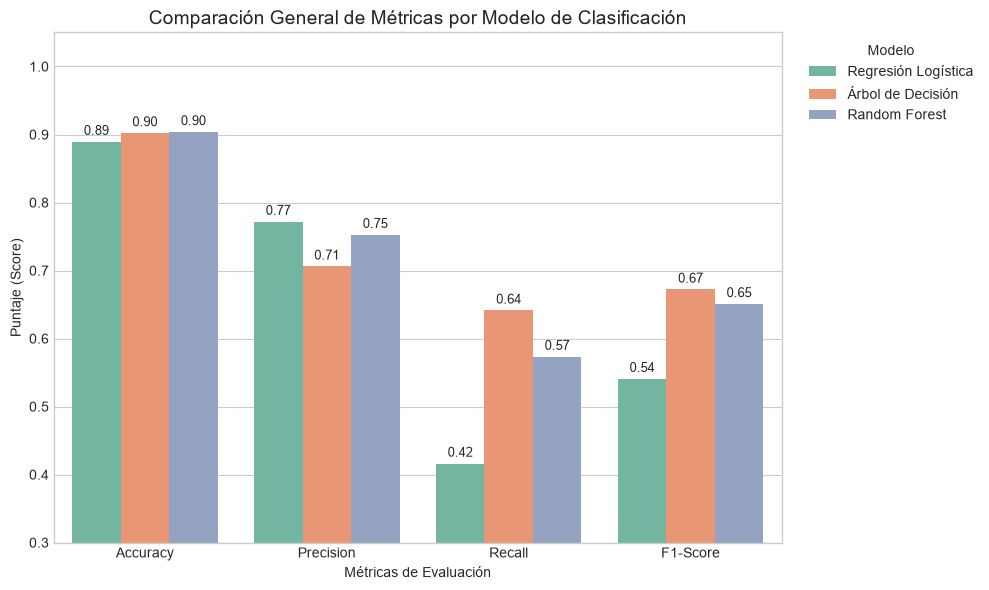

In [31]:

df_melted = metrics_df.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x='Métrica', y='Valor', hue='Modelo', palette='Set2')

plt.title('Comparación General de Métricas por Modelo de Clasificación', fontsize=14)
plt.ylim(0.3, 1.05)
plt.ylabel('Puntaje (Score)')
plt.xlabel('Métricas de Evaluación')
plt.legend(title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')

# Etiquetas sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

Matrices de Confusión 

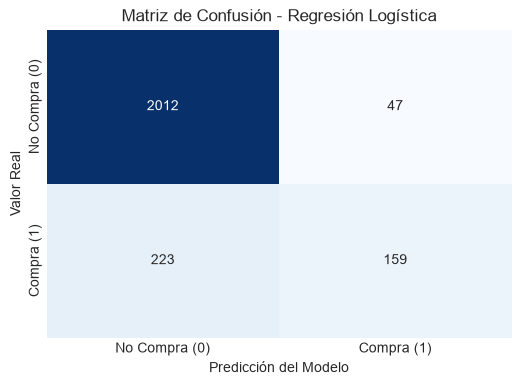

In [32]:
# Matriz de Confusión - Regresión Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Compra (0)', 'Compra (1)'],
            yticklabels=['No Compra (0)', 'Compra (1)'])
plt.title('Matriz de Confusión - Regresión Logística', fontsize=12)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

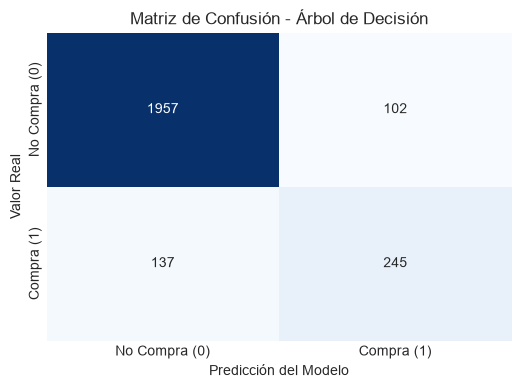

In [33]:
# Matriz de Confusión - Árbol de Decisión
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Compra (0)', 'Compra (1)'],
            yticklabels=['No Compra (0)', 'Compra (1)'])
plt.title('Matriz de Confusión - Árbol de Decisión', fontsize=12)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

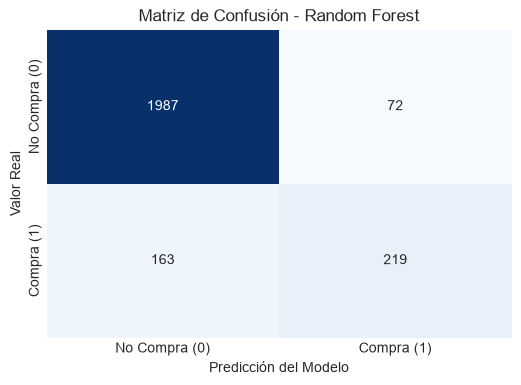

In [34]:
# Matriz de Confusión - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Compra (0)', 'Compra (1)'],
            yticklabels=['No Compra (0)', 'Compra (1)'])
plt.title('Matriz de Confusión - Random Forest', fontsize=12)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

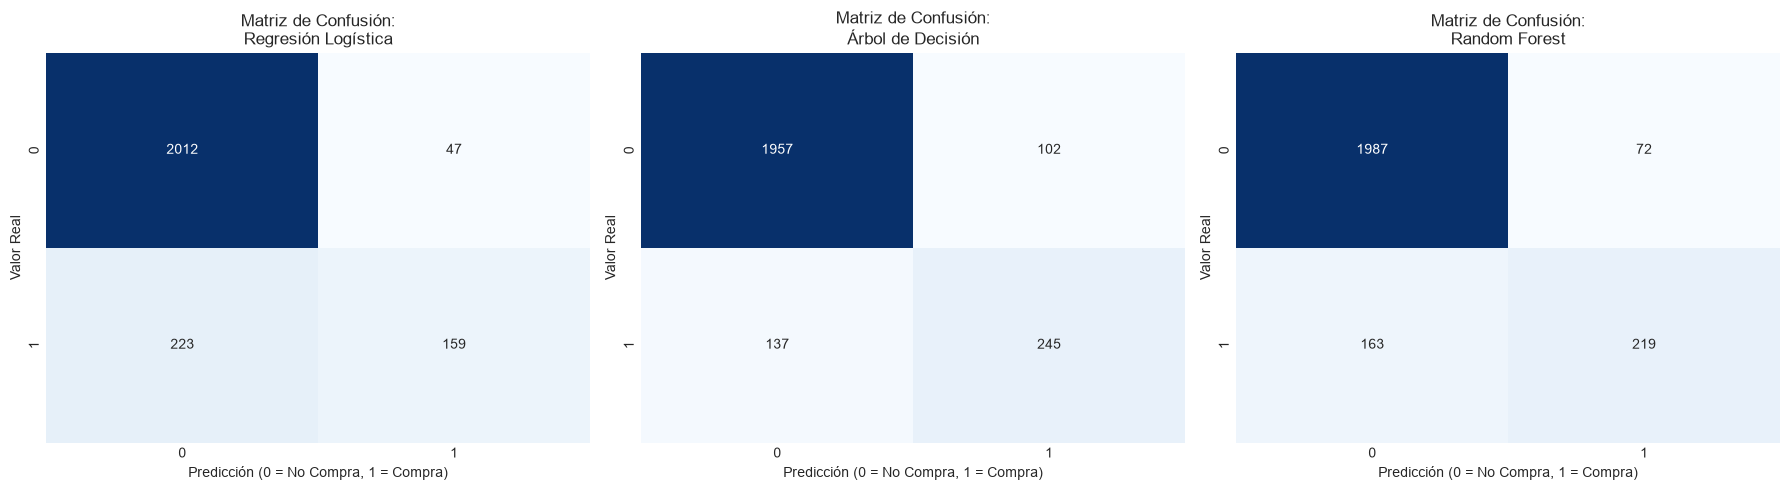

In [35]:
# Paso 7: Matrices de Confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Matriz de Confusión:\n{name}', fontsize=12)
    axes[i].set_xlabel('Predicción (0 = No Compra, 1 = Compra)')
    axes[i].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

## 6. Conclusiones

### **Respuesta a la Pregunta presentada:**
**Sí, es posible predecir si un visitante de una tienda en línea realizará una compra en función de su comportamiento durante la sesión.**

1. **Rendimiento:** Los tres modelos alcanzaron una exactitud (Accuracy) superior al 88-90% en la predicción
2. **Validación de modelos:** Random Forest obtuvo el mayor Accuracy (90.37%) y Precision (75%), mientras que el Árbol de Decisión obtuvo el mayor Recall (64%) y F1-Score (67%). Por lo tanto, la elección del modelo depende del objetivo de la predicción. Si se busca maximizar la exactitud general y la precisión de las predicciones positivas, Random Forest presenta ventajas. Sin embargo, si se busca un mayor equilibrio entre Precision y Recall para identificar compradores, el Árbol de Decisión presenta el mejor F1-Score.
3. **Variables Críticas**:En e-commerce, un Falso Positivo (FP) cuesta dinero porque podrían aplicarse descuentos o promociones a clientes que según el modelo realizaran una compra cuando en realidad no.